## Visualize the 3 fidelities together

In [1]:
# ## Load and aggregate the three normalized metrics

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
FIDELITY_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/eth_micron")

MARGINAL_PATH = FIDELITY_DIR / "emd_gen_true_normalized.csv"
BIVARIATE_PATH = FIDELITY_DIR / "corrdiff_gen_true_normalized.csv"
JOINT_PATH = FIDELITY_DIR / "joint_emd_gen_true_normalized.csv"

marginal_df = pd.read_csv(MARGINAL_PATH)
bivariate_df = pd.read_csv(BIVARIATE_PATH)
joint_df = pd.read_csv(JOINT_PATH)

print("marginal_df:", marginal_df.shape)
print("bivariate_df:", bivariate_df.shape)
print("joint_df:", joint_df.shape)

display(marginal_df.head())
display(bivariate_df.head())
display(joint_df.head())

marginal_df: (1540, 10)
bivariate_df: (4620, 14)
joint_df: (220, 11)


,model,seed,adm1,variable,emd_distance,emd_ub,emd_lb,denom,emd_norm_raw,emd_norm
0,cNF,1,Addis Ababa,va_ai,74.152263,21.723378,264.386232,242.662855,0.216056,0.216056
1,cNF,1,Addis Ababa,fol_ai,15.827171,8.725849,147.064524,138.338675,0.051333,0.051333
2,cNF,1,Addis Ababa,vb12_ai,0.407747,0.051379,0.790443,0.739065,0.482188,0.482188
3,cNF,1,Addis Ababa,fe_ai,1.569361,0.504544,11.777079,11.272535,0.094461,0.094461
4,cNF,1,Addis Ababa,zn_ai,0.802026,0.247748,6.124782,5.877034,0.094312,0.094312


,model,seed,adm1,var1,var2,pair,corr_real,corr_syn,corrdiff,corrdiff_ub,corrdiff_lb,denom,corrdiff_norm_raw,corrdiff_norm
0,cNF,1,Addis Ababa,va_ai,fol_ai,va_ai__fol_ai,0.609159,0.654873,0.045714,0.007767,0.652496,0.644729,0.058858,0.058858
1,cNF,1,Addis Ababa,va_ai,vb12_ai,va_ai__vb12_ai,0.323092,0.262515,0.060577,0.000051,0.366703,0.366652,0.165079,0.165079
2,cNF,1,Addis Ababa,va_ai,fe_ai,va_ai__fe_ai,0.474639,0.431440,0.043200,0.044299,0.431548,0.387249,-0.002839,0.000000
3,cNF,1,Addis Ababa,va_ai,zn_ai,va_ai__zn_ai,0.363683,0.367237,0.003554,0.026989,0.389024,0.362035,-0.064732,0.000000
4,cNF,1,Addis Ababa,va_ai,avg_adult_education,va_ai__avg_adult_education,0.135754,0.127859,0.007896,0.032583,0.077124,0.044540,-0.554281,0.000000


,model,seed,adm1,joint_emd,n_real,n_syn,emd_ub,emd_lb,denom,emd_norm_raw,emd_norm
0,cNF,1,Addis Ababa,1.091109,782,782,0.444510,2.391962,1.947452,0.332023,0.332023
1,cNF,1,Afar,1.012940,492,492,0.405243,2.328329,1.923086,0.316001,0.316001
2,cNF,1,Amhara,1.182509,759,759,0.373457,1.886362,1.512905,0.534767,0.534767
3,cNF,1,B. Gumuz,1.306303,333,333,0.486628,1.652162,1.165534,0.703261,0.703261
4,cNF,1,Dire Dawa,1.478600,459,459,0.469041,2.072414,1.603373,0.629647,0.629647


In [3]:
# Average marginal over variables for each (model, seed, adm1)
marginal_avg = (
    marginal_df
    .groupby(["model", "seed", "adm1"], as_index=False)
    .agg(
        marginal_norm=("emd_norm", "mean")
    )
)

# Average bivariate over pairs for each (model, seed, adm1)
bivariate_avg = (
    bivariate_df
    .groupby(["model", "seed", "adm1"], as_index=False)
    .agg(
        bivariate_norm=("corrdiff_norm", "mean")
    )
)

# Joint is already one value per (model, seed, adm1)
joint_avg = (
    joint_df[["model", "seed", "adm1", "emd_norm"]]
    .rename(columns={"emd_norm": "joint_norm"})
    .copy()
)

display(marginal_avg.head())
display(bivariate_avg.head())
display(joint_avg.head())

,model,seed,adm1,marginal_norm
0,CTGAN,1,Addis Ababa,0.339686
1,CTGAN,1,Afar,0.257385
2,CTGAN,1,Amhara,0.464041
3,CTGAN,1,B. Gumuz,0.567359
4,CTGAN,1,Dire Dawa,0.291292


,model,seed,adm1,bivariate_norm
0,CTGAN,1,Addis Ababa,0.500287
1,CTGAN,1,Afar,0.477530
2,CTGAN,1,Amhara,0.338185
3,CTGAN,1,B. Gumuz,0.330031
4,CTGAN,1,Dire Dawa,0.507532


,model,seed,adm1,joint_norm
0,cNF,1,Addis Ababa,0.332023
1,cNF,1,Afar,0.316001
2,cNF,1,Amhara,0.534767
3,cNF,1,B. Gumuz,0.703261
4,cNF,1,Dire Dawa,0.629647


In [4]:
# Merge the 3 metrics so each row is one (model, seed, adm1)
metrics_3way = (
    marginal_avg
    .merge(bivariate_avg, on=["model", "seed", "adm1"], how="inner")
    .merge(joint_avg, on=["model", "seed", "adm1"], how="inner")
    .copy()
)

print("metrics_3way shape:", metrics_3way.shape)
display(metrics_3way.head())

metrics_3way shape: (220, 6)


,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,Addis Ababa,0.339686,0.500287,0.529672
1,CTGAN,1,Afar,0.257385,0.477530,0.630813
2,CTGAN,1,Amhara,0.464041,0.338185,0.945793
3,CTGAN,1,B. Gumuz,0.567359,0.330031,1.000000
4,CTGAN,1,Dire Dawa,0.291292,0.507532,0.597680


In [5]:
# Optional: save merged table
OUT_PATH = FIDELITY_DIR / "merged_marginal_bivariate_joint_normalized.csv"
metrics_3way.to_csv(OUT_PATH, index=False)
print(f"Saved merged table to: {OUT_PATH}")

Saved merged table to: /data/shared/fsibilla/clean_code/Q0/fidelity/eth_micron/merged_marginal_bivariate_joint_normalized.csv


In [6]:
# ## Prepare radar-plot summary
#
# We want:
# - for each model and seed: average across adm1
# - then across seeds: mean
# - and std based on the adm1-level variability after seed averaging

METRIC_COLS = ["marginal_norm", "bivariate_norm", "joint_norm"]

# Mean over adm1 within each seed
seed_level = (
    metrics_3way
    .groupby(["model", "seed"], as_index=False)[METRIC_COLS]
    .mean()
)

display(seed_level.head())

,model,seed,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,0.334368,0.405992,0.731976
1,CTGAN,2,0.333061,0.504807,0.755562
2,CTGAN,3,0.245252,0.389887,0.649844
3,CTGAN,4,0.340220,0.421448,0.748286
4,CTGAN,5,0.256338,0.426303,0.650661


In [7]:
# Mean and std across seeds for the central line
model_mean_std = (
    seed_level
    .groupby("model", as_index=False)
    .agg(
        marginal_mean=("marginal_norm", "mean"),
        marginal_std_seed=("marginal_norm", "std"),
        bivariate_mean=("bivariate_norm", "mean"),
        bivariate_std_seed=("bivariate_norm", "std"),
        joint_mean=("joint_norm", "mean"),
        joint_std_seed=("joint_norm", "std"),
    )
)

model_mean_std = model_mean_std.fillna(0.0)
display(model_mean_std)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed
0,CTGAN,0.301848,0.046847,0.429687,0.044350,0.707266,0.052743
1,NF,0.046040,0.008946,0.189571,0.024679,0.323907,0.008122
2,TVAE,0.386206,0.043692,0.402663,0.032642,0.644996,0.023659
3,cNF,0.164315,0.020232,0.274196,0.042557,0.453066,0.030771


In [8]:
# Std over adm1:
# first average across seeds for each (model, adm1), then compute std across adm1

adm1_level = (
    metrics_3way
    .groupby(["model", "adm1"], as_index=False)[METRIC_COLS]
    .mean()
)

model_adm1_std = (
    adm1_level
    .groupby("model", as_index=False)
    .agg(
        marginal_std_adm1=("marginal_norm", "std"),
        bivariate_std_adm1=("bivariate_norm", "std"),
        joint_std_adm1=("joint_norm", "std"),
    )
)

model_adm1_std = model_adm1_std.fillna(0.0)
display(model_adm1_std)

,model,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.087427,0.057751,0.196392
1,NF,0.008523,0.044082,0.091002
2,TVAE,0.198959,0.113347,0.237284
3,cNF,0.060002,0.087773,0.150327


In [9]:
# Final table for plotting
radar_df = (
    model_mean_std
    .merge(model_adm1_std, on="model", how="left")
    .fillna(0.0)
)

display(radar_df)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.301848,0.046847,0.429687,0.044350,0.707266,0.052743,0.087427,0.057751,0.196392
1,NF,0.046040,0.008946,0.189571,0.024679,0.323907,0.008122,0.008523,0.044082,0.091002
2,TVAE,0.386206,0.043692,0.402663,0.032642,0.644996,0.023659,0.198959,0.113347,0.237284
3,cNF,0.164315,0.020232,0.274196,0.042557,0.453066,0.030771,0.060002,0.087773,0.150327


In [10]:
# ## Spider / radar plot

MODEL_ORDER = ["cNF", #"NF", 
"TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in radar_df["model"].unique()]

MODEL_COLORS = {
    "cNF": "tab:blue",
    "NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

AXES_LABELS = ["Marginal", "Bivariate", "Joint"]
N_AXES = len(AXES_LABELS)

angles = np.linspace(0, 2 * np.pi, N_AXES, endpoint=False).tolist()
angles += angles[:1]  # close polygon

In [11]:
def close_vals(vals):
    vals = list(vals)
    return vals + vals[:1]

In [12]:
# Convert normalized errors into normalized fidelity scores
radar_score_df = radar_df.copy()

for col in [
    "marginal_mean", "bivariate_mean", "joint_mean",
]:
    radar_score_df[col] = 1.0 - radar_score_df[col]

display(radar_score_df)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.698152,0.046847,0.570313,0.044350,0.292734,0.052743,0.087427,0.057751,0.196392
1,NF,0.953960,0.008946,0.810429,0.024679,0.676093,0.008122,0.008523,0.044082,0.091002
2,TVAE,0.613794,0.043692,0.597337,0.032642,0.355004,0.023659,0.198959,0.113347,0.237284
3,cNF,0.835685,0.020232,0.725804,0.042557,0.546934,0.030771,0.060002,0.087773,0.150327


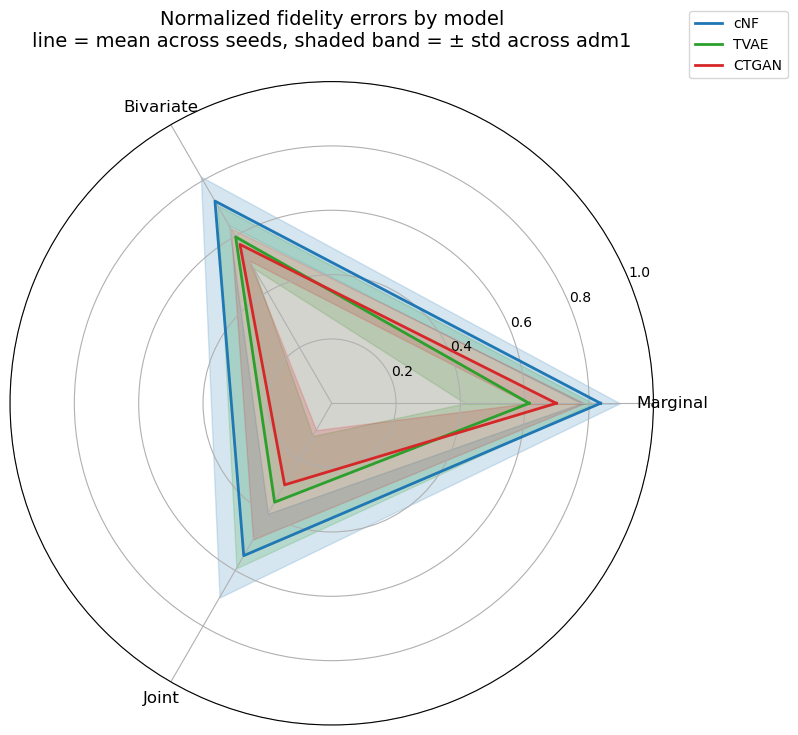

In [13]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for model in MODEL_ORDER:
    row = radar_score_df.loc[radar_score_df["model"] == model]
    if row.empty:
        continue
    row = row.iloc[0]

    means = [
        row["marginal_mean"],
        row["bivariate_mean"],
        row["joint_mean"],
    ]

    stds_adm1 = [
        row["marginal_std_adm1"],
        row["bivariate_std_adm1"],
        row["joint_std_adm1"],
    ]

    lower = np.clip(np.array(means) - np.array(stds_adm1), 0, 1)
    upper = np.clip(np.array(means) + np.array(stds_adm1), 0, 1)

    means_c = close_vals(means)
    lower_c = close_vals(lower)
    upper_c = close_vals(upper)

    color = MODEL_COLORS.get(model, "gray")

    ax.plot(
        angles,
        means_c,
        color=color,
        linewidth=2,
        label=model,
    )

    ax.fill(
        angles,
        means_c,
        color=color,
        alpha=0.10,
    )

    ax.fill_between(
        angles,
        lower_c,
        upper_c,
        color=color,
        alpha=0.18,
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(AXES_LABELS, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"])
ax.set_title(
    "Normalized fidelity errors by model\nline = mean across seeds, shaded band = ± std across adm1",
    pad=25,
    fontsize=14
)
ax.legend(loc="upper right", bbox_to_anchor=(1.22, 1.12))

plt.tight_layout()
plt.show()

## Look at originality too

In [14]:
# ## Load fidelity + recall

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
FIDELITY_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/eth_micron")
RECALL_DIR = Path("/data/shared/fsibilla/clean_code/Q0/recall/eth_micron")

FIDELITY_3WAY_PATH = FIDELITY_DIR / "merged_marginal_bivariate_joint_normalized.csv"
RECALL_PATH = RECALL_DIR / "recall_gen_true_by_adm1.csv"

fidelity_3way = pd.read_csv(FIDELITY_3WAY_PATH)
recall_df = pd.read_csv(RECALL_PATH)

print("fidelity_3way:", fidelity_3way.shape)
print("recall_df:", recall_df.shape)

display(fidelity_3way.head())
display(recall_df.head())

fidelity_3way: (220, 6)
recall_df: (220, 8)


,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,Addis Ababa,0.339686,0.500287,0.529672
1,CTGAN,1,Afar,0.257385,0.477530,0.630813
2,CTGAN,1,Amhara,0.464041,0.338185,0.945793
3,CTGAN,1,B. Gumuz,0.567359,0.330031,1.000000
4,CTGAN,1,Dire Dawa,0.291292,0.507532,0.597680


,model,seed,adm1,recall,matched_real,n_real,n_syn,radius
0,cNF,1,Addis Ababa,0.391304,306,782,782,0.5
1,cNF,1,Afar,0.581301,286,492,492,0.5
2,cNF,1,Amhara,0.545455,414,759,759,0.5
3,cNF,1,B. Gumuz,0.255255,85,333,333,0.5
4,cNF,1,Dire Dawa,0.283224,130,459,459,0.5


In [16]:
# Average the 3 fidelity metrics into one fidelity score (still an error, so lower is better)
fidelity_3way = fidelity_3way.copy()

fidelity_3way["fidelity_mean"] = fidelity_3way[
    ["marginal_norm", "bivariate_norm", "joint_norm"]
].mean(axis=1)

display(fidelity_3way.head())

,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm,fidelity_mean
0,CTGAN,1,Addis Ababa,0.339686,0.500287,0.529672,0.456548
1,CTGAN,1,Afar,0.257385,0.477530,0.630813,0.455243
2,CTGAN,1,Amhara,0.464041,0.338185,0.945793,0.582673
3,CTGAN,1,B. Gumuz,0.567359,0.330031,1.000000,0.632463
4,CTGAN,1,Dire Dawa,0.291292,0.507532,0.597680,0.465501


In [17]:
# Keep only the columns needed for the merge
fidelity_for_merge = fidelity_3way[
    ["model", "seed", "adm1", "fidelity_mean"]
].copy()

recall_for_merge = recall_df[
    ["model", "seed", "adm1", "recall"]
].copy()

plot_source = (
    fidelity_for_merge
    .merge(recall_for_merge, on=["model", "seed", "adm1"], how="inner")
    .copy()
)

print("plot_source shape:", plot_source.shape)
display(plot_source.head())

plot_source shape: (220, 5)


,model,seed,adm1,fidelity_mean,recall
0,CTGAN,1,Addis Ababa,0.456548,0.219949
1,CTGAN,1,Afar,0.455243,0.382114
2,CTGAN,1,Amhara,0.582673,0.396574
3,CTGAN,1,B. Gumuz,0.632463,0.207207
4,CTGAN,1,Dire Dawa,0.465501,0.237473


In [18]:
# One scatter point per model with x/y std dev error bars
model_summary = (
    plot_source
    .groupby("model", as_index=False)
    .agg(
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        fidelity_mean=("fidelity_mean", "mean"),
        fidelity_std=("fidelity_mean", "std"),
        n_rows=("recall", "count"),
    )
)

model_summary["recall_std"] = model_summary["recall_std"].fillna(0.0)
model_summary["fidelity_std"] = model_summary["fidelity_std"].fillna(0.0)

display(model_summary)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows
0,CTGAN,0.299544,0.124474,0.479600,0.096457,55
1,NF,0.458094,0.138874,0.186506,0.044956,55
2,TVAE,0.322316,0.183173,0.477955,0.151162,55
3,cNF,0.428206,0.143153,0.297192,0.094428,55


In [19]:
MODEL_ORDER = ["cNF", #"NF",
 "TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in model_summary["model"].unique()]

MODEL_COLORS = {
    "cNF": "tab:blue",
    #"NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

model_summary = (
    model_summary
    .set_index("model")
    .loc[MODEL_ORDER]
    .reset_index()
)

display(model_summary)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows
0,cNF,0.428206,0.143153,0.297192,0.094428,55
1,TVAE,0.322316,0.183173,0.477955,0.151162,55
2,CTGAN,0.299544,0.124474,0.479600,0.096457,55


In [20]:
model_summary_plot = model_summary.copy()
model_summary_plot["fidelity_score"] = 1.0 - model_summary_plot["fidelity_mean"]

display(model_summary_plot)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows,fidelity_score
0,cNF,0.428206,0.143153,0.297192,0.094428,55,0.702808
1,TVAE,0.322316,0.183173,0.477955,0.151162,55,0.522045
2,CTGAN,0.299544,0.124474,0.479600,0.096457,55,0.520400


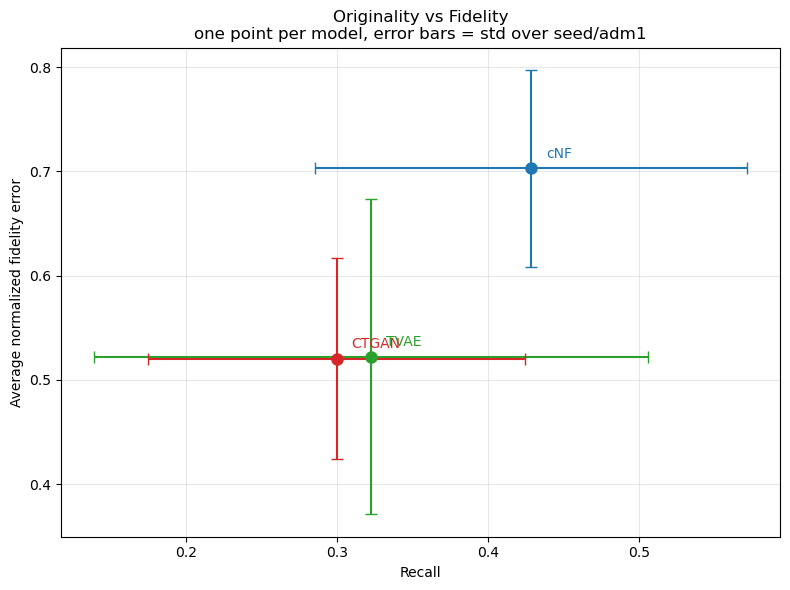

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in model_summary_plot.iterrows():
    model = row["model"]
    x = row["recall_mean"]
    y = row["fidelity_score"]
    xerr = row["recall_std"]
    yerr = row["fidelity_std"]
    color = MODEL_COLORS.get(model, "gray")

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        yerr=yerr,
        fmt="o",
        capsize=4,
        markersize=8,
        color=color,
        ecolor=color,
        elinewidth=1.5,
        label=model,
    )

    ax.text(
        x + 0.01,
        y + 0.01,
        model,
        fontsize=10,
        color=color,
    )

ax.set_xlabel("Recall")
ax.set_ylabel("Average normalized fidelity error")
ax.set_title("Originality vs Fidelity\none point per model, error bars = std over seed/adm1")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()